# Archimedes: the load on a submerged cylinder

A fixed circular cylinder of radius $R$ sits in a tank of still water. Two exact statements fix the loads on the bodies in the steady state:

* the force of the water on the cylinder is the **buoyancy**, $F_y=\rho g\,\pi R^2$ upward and $F_x=0$ by symmetry;
* the loads on **all** walls (tank and cylinder) add up to the weight of the fluid actually present, $F_{y,\mathrm{tank}}+F_{y,\mathrm{cyl}}=-\rho g\,A_\mathrm{fluid}$ (the global momentum balance of a fluid at rest).

This is a test of the *pressure* load on a curved wall: the wall pressure condition, the hydrostatic extrapolation to the wall, the load booking and the free surface above the body.
The cylinder is one exact analytic disk (`DiskArrayRep`); choose the solver with `SCHEME`.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.scene.scene import Body, DiskArrayRep, Scene
from warpSPHBoundaries.sim.dfsph2d import carve, domain_scene, lattice_calibration, PACKING
from warpSPHBoundaries.sim.solvers import make_solver, box_lattice, lattice_constants

g = 9.81
Ltank, Htank, depth, R = 0.6, 0.45, 0.30, 0.08
n = {"quick": 60, "full": 100}[QUALITY]                 # particles per unit length
T = {"quick": 1.0, "full": 1.5}[QUALITY]
dx = 1.0 / n

## Set-up
The cylinder is centred 0.13 below the surface; the lattice is cut around it at the scheme's wall gap (`delta`: half a spacing; `dfsph`: the volume-consistent carve of its lattice calibration).

In [3]:
cells = (int(round(Ltank / dx)), int(round(depth / dx)))
pos, hi = box_lattice(SCHEME, (0.0, 0.0), cells, dx, walls=(True, False))
top = pos[:, 1].max() + 0.5 * dx
centre = (0.5 * hi[0], top - 0.13)
body = Body(bodyId=1, center=centre, reps=[DiskArrayRep([(0.0, 0.0)], [R])])
if SCHEME == "delta":
    pos = pos[np.linalg.norm(pos - centre, axis=1) >= R + 0.5 * dx]
else:
    cal = lattice_calibration(dx, dx, dx / PACKING)
    pos = carve(pos, [body], dx / PACKING, cal["lamCell"], DEVICE)
h = lattice_constants(SCHEME, dx)["h"]
tank = domain_scene("surface", (0.0, 0.0), (hi[0], Htank), h, DEVICE).bodies[0]
tank.bodyId = 0
scene = Scene([tank, body], DEVICE)
c0 = 10.0 * math.sqrt(g * depth)
extra = {"maxDt": 1e-3} if SCHEME == "dfsph" else {}
sol = make_solver(SCHEME, pos, dx, scene, nu=0.0, gravity=(0.0, -g), c0=c0, device=DEVICE, **extra)
if SCHEME == "delta":                                    # hydrostatic start
    import torch
    sol.sim.rho = sol.sim.rho * (1.0 + g * torch.as_tensor(np.clip(top - pos[:, 1], 0, None), device=DEVICE) / c0 ** 2)
weight = g * float(sol.volume.sum())
buoy = g * math.pi * R * R
print(f"scheme {SCHEME}: N = {sol.n}, weight of the water {weight:.3f}, buoyancy rho g pi R^2 = {buoy:.4f}")

t, Fc, Ft = [], [], []
def record(s):
    t.append(s.time); Fc.append(s.loads(1)); Ft.append(s.loads(0))

scheme delta: N = 562, weight of the water 1.524, buoyancy rho g pi R^2 = 0.1972


## Integration

In [4]:
sol.run(T, every=T / 3, callback=record, report=lambda s: f"cylinder load ({Fc[-1][0]:+.3f}, {Fc[-1][1]:+.3f})")

  t    0.334  dt 6.14e-04  vmax    0.139  cylinder load (+0.000, +0.183)  [11 s]


  t    0.667  dt 6.14e-04  vmax    0.222  cylinder load (-0.000, +0.187)  [26 s]


  t    1.000  dt 6.14e-04  vmax    0.194  cylinder load (+0.000, +0.195)  [41 s]


True

## Loads against the exact values

cylinder: F = (-0.0000, +0.2125);  buoyancy 0.1972  -> F_y / buoyancy = 1.0774, |F_x| / buoyancy = 0.0000
tank + cylinder: F_y = -1.5301;  weight of the fluid 1.5237 -> ratio 1.0042


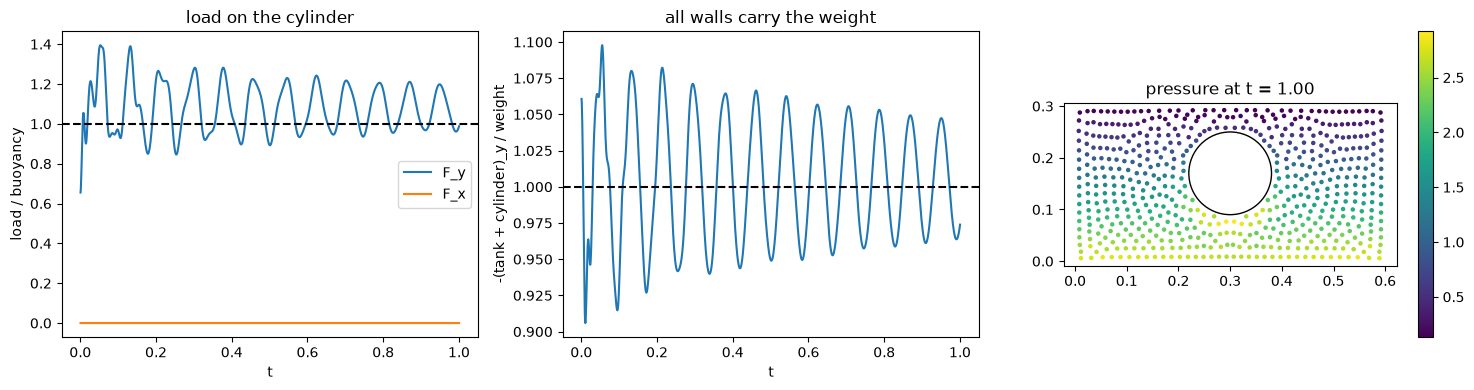

In [5]:
t, Fc, Ft = np.array(t), np.array(Fc), np.array(Ft)
m = t > 0.5 * T
fc, ft = Fc[m].mean(0), Ft[m].mean(0)
print(f"cylinder: F = ({fc[0]:+.4f}, {fc[1]:+.4f});  buoyancy {buoy:.4f}  -> F_y / buoyancy = {fc[1] / buoy:.4f}, |F_x| / buoyancy = {abs(fc[0]) / buoy:.4f}")
print(f"tank + cylinder: F_y = {ft[1] + fc[1]:+.4f};  weight of the fluid {weight:.4f} -> ratio {-(ft[1] + fc[1]) / weight:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(t, Fc[:, 1] / buoy, label="F_y"); ax[0].plot(t, Fc[:, 0] / buoy, label="F_x"); ax[0].axhline(1, color="k", ls="--"); ax[0].set(xlabel="t", ylabel="load / buoyancy", title="load on the cylinder"); ax[0].legend()
ax[1].plot(t, -(Ft[:, 1] + Fc[:, 1]) / weight); ax[1].axhline(1, color="k", ls="--"); ax[1].set(xlabel="t", ylabel="-(tank + cylinder)_y / weight", title="all walls carry the weight")
q = ax[2].scatter(sol.x[:, 0], sol.x[:, 1], c=sol.pressure, s=5); ax[2].add_patch(plt.Circle(centre, R, color="k", fill=False)); ax[2].set(aspect="equal", title=f"pressure at t = {sol.time:.2f}"); plt.colorbar(q, ax=ax[2])
plt.tight_layout(); plt.show()

## What to look at

* `F_y / buoyancy` is the accuracy of the pressure load on a curved wall; a few per cent at this resolution (it converges with the lattice spacing: the cylinder is only $R/dx = 4.8$ spacings in radius in the quick run);
* the second ratio is the global momentum balance of the wall loads and the fluid — independent of the wall model — and should be 1 within the noise of the booking.